# PhasemeterClient — quick start
This notebook shows how to use the `PhasemeterClient` class to connect,
configure, measure the phase difference (Δφ = φ₂ − φ₁), and sweep frequency
to plot Δφ as a function of frequency.

In [7]:
from phasemeter_client_fixed import PhasemeterClient
# Fill in the target of your Moku (e.g., '192.168.1.100' or link-local IPv6)
TARGET = '[fe80::7269:79ff:feb7:d15%6]'  # <-- replace if needed
client = PhasemeterClient(
    target=TARGET,
    phase_units='cycles',   # or 'deg' depending on API
    wrap_output=True,
    input_range='1Vpp',
    impedance='50Ohm',
    coupling='DC',
    pll_bandwidth='1kHz',
    poll_sec=0.5,
)
client.load(f0_hz=5e6)  # optional initial lock


## Change device settings on the fly

In [8]:
# Change front-end input range for channel 1, then both
client.set_frontend(1, input_range='1Vpp')
client.set_frontend(2, input_range='1Vpp')
# Change PLL bandwidth for both channels
client.set_bandwidth_all('10kHz')
# Move center frequency (both channels track the same f)
client.set_frequency_all(15e6)


## Read a single phase-difference sample

In [12]:
dphi_deg, frame = client.read_phase_difference_deg()
print('Δφ [deg]:', dphi_deg)
print('f1 [Hz]:', frame['ch1']['frequency'], 'f2 [Hz]:', frame['ch2']['frequency'])


Δφ [deg]: 136.2595921754837
f1 [Hz]: 15000008.224577144 f2 [Hz]: 15000008.246483177


## Optional: Live Δφ vs. time (stop with **Kernel → Interrupt** or `Ctrl+C` in terminal)

In [13]:
client.live_plot_delta_phi_vs_time_jupyter(window_s=30, print_every_s=1.0)
# (commented out to avoid blocking in notebook)



Stopped by user.


## Δφ vs. frequency sweep

        f [Hz]     Δφ [deg]
---------------------------
   5000000.000      -68.856
   5947368.421      -46.613
   6894736.842      -17.527
   7842105.263       70.123
   8789473.684       13.757
   9736842.105       15.281
  10684210.526       13.087
  11631578.947      104.120
  12578947.368      -46.678
  13526315.789       74.079
  14473684.211       32.174
  15421052.632      -55.171
  16368421.053      -43.232
  17315789.474       11.341
  18263157.895       11.127
  19210526.316       92.192
  20157894.737       14.007
  21105263.158       12.557
  22052631.579      -32.586
  23000000.000      -47.786


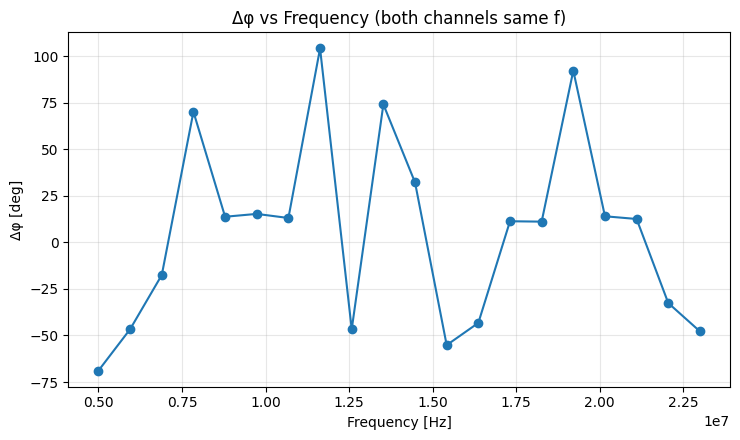

In [13]:
import numpy as np
# Define a frequency list (both channels use the same frequency at each step)
freqs = np.linspace(5e6, 23e6, 20)  # 5–23 MHz, 17 points
sweep = client.sweep_phase_vs_frequency(
    freqs, settle_s=0.2, samples_per_point=5, average='median', reacquire_each_step=True
)
client.print_sweep(sweep)
client.plot_sweep(sweep, title='Δφ vs Frequency (both channels same f)')


## Clean up

In [23]:
client.close()
